In [20]:
import os, sys
os.environ['CHIMERA_ENABLE_GPU'] = "False"
sys.path.append(os.getcwd()+'/../')
import jax.numpy as jnp
import matplotlib.pyplot as plt
from CHIMERA.population.mass.paired import neural_density
from CHIMERA.population.mass import p_m1m2, p_m1, pdf_joint_and_marg

model = neural_density(hidden_size=4, depth=1)
print("Z (2D norm) at fiducial:", model.norm_2d)
model

Z (2D norm) at fiducial: 66.97489593236867


neural_density(
  m_low=4.58,
  m_high=86.3,
  m_grid=f64[500],
  norm_2d=f64[],
  keys=[
    'm_low',
    'm_high',
    'beta',
    'bottomsmooth',
    'topsmooth',
    'input_size',
    'hidden_size',
    'depth',
    'Ws',
    'bs'
  ],
  input_size=1,
  hidden_size=4,
  depth=1,
  Ws=[f64[4,1], f64[1,4]],
  bs=[f64[4]],
  beta=1.08,
  bottomsmooth=3.3,
  topsmooth=3.3
)

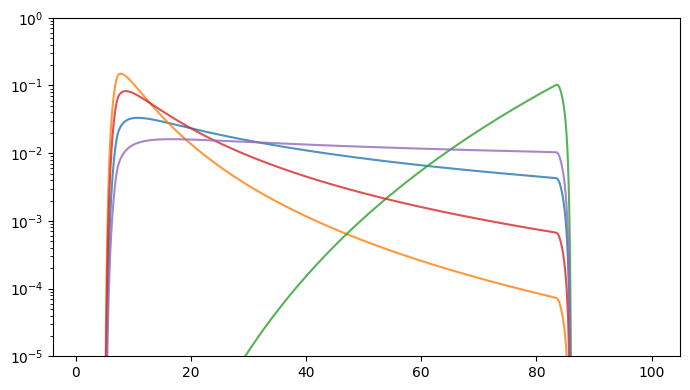

In [27]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

def sample_random_params(input_size, hidden_size, depth, key, scale=0.2):
  sizes = [input_size] + [hidden_size] * depth
  keys = jax.random.split(key, depth + 1)
  Ws, bs = [], []
  for i in range(depth):
    w_key, b_key = jax.random.split(keys[i])
    Ws.append(scale * jax.random.normal(w_key, (sizes[i + 1], sizes[i])))
    bs.append(scale * jax.random.normal(b_key, (sizes[i + 1],)))

  Ws.append(scale * jax.random.normal(keys[-1], (1, hidden_size)))
  return Ws, bs

# ---------------------------------------------------------------------------
# A few random realizations, overlaid on the marginal
# ---------------------------------------------------------------------------

n_realizations = 5
master_key = jax.random.PRNGKey(1)
keys = jax.random.split(master_key, n_realizations)

input_size = model.input_size
hidden_size = model.hidden_size
depth = model.depth

fig, ax = plt.subplots(1, 1, figsize=(7, 4))

m1 = jnp.linspace(1,100,5000)

for i, key in enumerate(keys):
  Ws, bs = sample_random_params(input_size, hidden_size, depth, key, scale=1)
  model_rand = model.update(Ws=Ws, bs=bs)

  pdf = p_m1(model_rand, m1)
  ax.plot(m1, pdf, alpha=0.8, label=f"draw {i}")
  ax.set_yscale('log')
  ax.set_ylim(1e-5,1)  

fig.tight_layout()
plt.show()

In [23]:
m1 = jnp.linspace(10,80,5000)
m1 = jnp.array([m1 for _ in range(300)]).T
m2 = m1*0.8

@jax.jit
def jitted_p_m1m2(model, m1, m2):
    return p_m1m2(model, m1, m2)

jitted_p_m1m2(model_rand, m1, m2)

Array([[0.00350959, 0.00350959, 0.00350959, ..., 0.00350959, 0.00350959,
        0.00350959],
       [0.00350209, 0.00350209, 0.00350209, ..., 0.00350209, 0.00350209,
        0.00350209],
       [0.00349462, 0.00349462, 0.00349462, ..., 0.00349462, 0.00349462,
        0.00349462],
       ...,
       [0.00016986, 0.00016986, 0.00016986, ..., 0.00016986, 0.00016986,
        0.00016986],
       [0.00016981, 0.00016981, 0.00016981, ..., 0.00016981, 0.00016981,
        0.00016981],
       [0.00016977, 0.00016977, 0.00016977, ..., 0.00016977, 0.00016977,
        0.00016977]], dtype=float64)

In [24]:
%timeit -n 10 jitted_p_m1m2(model_rand, m1, m2).block_until_ready()

137 ms ± 67.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [5]:
from CHIMERA.population.mass.paired import bpl_dip_three_peaks

model_2 = bpl_dip_three_peaks()
jitted_p_m1m2(model_2, m1, m2)
%timeit -n 10 jitted_p_m1m2(model_2, m1, m2).block_until_ready()

311 ms ± 17.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


hidden_size = 5


(1e-05, 1)

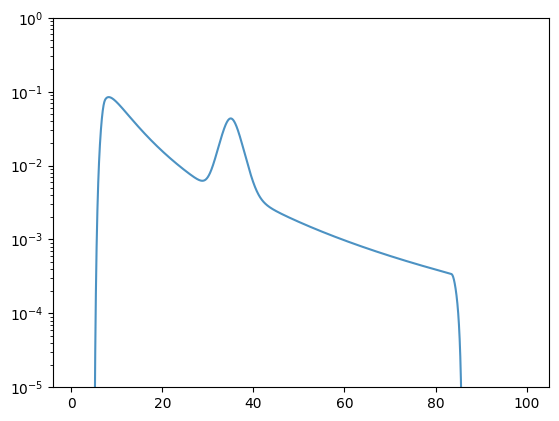

In [34]:
"""Hand-construct (Ws, bs) for a depth=1 neural_density MLP so that

    g(x) = (1 - alpha) * x + sum_k bump_k(x),      x = log(m)

reproducing p_tilde(m) ~ m^-alpha away from the bumps, with a triangular
"bump" of chosen center/width/amplitude in log-mass superimposed on top
of the power law for each entry in `bumps`.

Only works with `depth=1` (single hidden layer feeding straight into the
bias-free linear output) -- that's what makes both building blocks exact:

  - power-law slope: softplus(z) - softplus(-z) = z  (exact linear, any z)
  - each bump: ReLU(x-a) - 2*ReLU(x-b) + ReLU(x-c) is an exact triangle
    peaking at x=b with height (b-a); softplus(s*z)/s -> ReLU(z) as
    s -> inf, so 3 softplus units approximate the same tent, with `s`
    controlling how sharp/rounded the peak is.
"""

import jax.numpy as jnp


def make_powerlaw_bumps_params(alpha, bumps, sharpness=50.0, b0=0.0):
  """Exact (Ws, bs) for a depth=1 log-density MLP: power law + bumps.

  Parameters
  ----------
  alpha : float
      Power-law index: p_tilde(m) ~ m^-alpha away from the bumps
      (alpha > 0 -> decreasing with mass, the usual convention).
  bumps : list[dict]
      Each dict: ``{"center": mu, "width": w, "amplitude": A}``, all in
      *log-mass* units (``x = log(m)``). The bump spans
      ``[mu - w, mu + w]`` and peaks at ``mu`` with height ~``A``
      (exact as ``sharpness -> inf``; a finite ``sharpness`` rounds the
      peak and slightly reduces its height).
  sharpness : float
      Softplus steepness for the tent corners. Larger = closer to an
      exact triangle; too large can make the transition region span
      only a few grid points, so keep `mass.m_grid_res` fine enough to
      resolve it, or lower `sharpness`.
  b0 : float
      Overall additive constant. Purely cosmetic -- degenerate with the
      CHIMERA normalization (g -> g + c leaves p(m1,m2) unchanged).

  Returns
  -------
  Ws, bs : the depth=1 weight/bias lists, ready for
      ``model.update(Ws=Ws, bs=bs, hidden_size=Ws[0].shape[0], depth=1)``.
  """
  w_in, b_in, w_out = [], [], []

  # --- power-law slope: exact via softplus(z) - softplus(-z) = z ---
  slope = 1.0 - alpha
  w_in += [slope, -slope]
  b_in += [b0, -b0]
  w_out += [1.0, -1.0]

  # --- bumps: exact triangular tent via 3 softplus ("soft-ReLU") units ---
  for bump in bumps:
    mu, w, A = bump["center"], bump["width"], bump["amplitude"]
    a, c = mu - w, mu + w
    s = sharpness
    w_in += [s, s, s]
    b_in += [-s * a, -s * mu, -s * c]
    h = A / (w * s)
    w_out += [h, -2 * h, h]

  hidden_size = len(w_in)
  Ws = [
    jnp.array(w_in).reshape(hidden_size, 1),   # input layer, input_size=1
    jnp.array(w_out).reshape(1, hidden_size),  # bias-free output layer
  ]
  bs = [jnp.array(b_in)]

  return Ws, bs


bumps = [
#{"center": float(jnp.log(60.0)), "width": 0.5, "amplitude": 1},    
{"center": float(jnp.log(35.0)), "width": 0.15, "amplitude": 3.0},
#{"center": float(jnp.log(10.0)), "width": 0.10, "amplitude": 1.5},
]
Ws, bs = make_powerlaw_bumps_params(alpha=2.3, bumps=bumps, sharpness=40.0)

model_to_test = model.update(Ws=Ws, bs=bs, hidden_size=Ws[0].shape[0])
print("hidden_size =", Ws[0].shape[0])

pdf = p_m1(model_to_test, m1)
plt.plot(m1, pdf, alpha=0.8, label=f"draw {i}")
plt.yscale('log')
plt.ylim(1e-5,1)  

In [35]:
Ws 

[Array([[-1.3],
        [ 1.3],
        [40. ],
        [40. ],
        [40. ]], dtype=float64),
 Array([[ 1. , -1. ,  0.5, -1. ,  0.5]], dtype=float64)]